# Modelación de la componente $u=c_1 - c_2=SO_4^{2-}-Ca^{2+}$

Flujo y transporte conservativo en 1D utilizando GWF, GWT y Flopy. 

$$
\frac{\partial}{\partial x}( K \frac{\partial h }{\partial x})+ q_s = S_s \frac{\partial h }{\partial t} $$

$$
    \frac {\partial\left(\theta C^k\right)}{\partial t}  = \frac{\partial}{\partial x}\left(\theta D \frac{\partial C^k}{\partial x}\right)- \frac{\partial}{\partial x} (\theta v C^k) + q_s C^{k}_{s} 
$$

<a href="https://github.com/luiggix/RTWMA">RTWMA</a> © 2024-2026 by <a href="https://www.geofisica.unam.mx">IGF-UNAM</a> is licensed under <a href="https://creativecommons.org/licenses/by-nc/4.0/">CC BY-NC 4.0</a><img src="https://mirrors.creativecommons.org/presskit/icons/cc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/by.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/nc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;">


## Discretización del tiempo.

|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|Number of stress periods (NPER) | $1$ | | `tdis["nper"]` |
|Total time | $40$ | days | `tdis["perioddata"][0][0]` |
|Number of time steps (NSTP) | $40$ | | `tdis["perioddata"][0][1]` |
|Multiplier (TSMULT)| $1$ | | `tdis["perioddata"][0][2]` |

## Discretización espacial.

<img src="./dominiou.png" width=600px>

|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|Length of system (rows) | $30.0$ | m | |
|Number of layers | $1$ | | `dis["nlay"]`|
|Number of rows | $1$ | | `dis["nrow"]`|
|Number of columns | $30$ | | `dis["ncol"]`|
|Column width | $1.0$ | m | `dis["delr"]`|
|Row width | $1.0$ | m | `dis["delc"]`|
|Top of the model | $1.0$ | m | `dis["top"]`|
|Layer bottom elevation (cm) | $0$ | m | `dis["botm"]`|

## Parámetros físicos.

|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|Specific discharge |$0.2$| m d$^{-1}$ | `phys["specific_discharge"]` |
|Hydraulic conductivity |$1.0$| m d$^{-1}$ | `phys["hydraulic_conductivity"]` |
|Source concentration |$1.0000329$| unitless | `phys["source_concentration"]` |
|Porosity | $0.5$ | unitless |  `phys["porosity"]` |
|Initial Concentration | $u_{1_i} = 1.0$, $u_{1_{12_i}} = 199.999967$ | unitless | `phys["initial_concentration"]` |
|Longitudinal Dispersivity | $0.2$ |  | `phys["longitudinal_dispersivity"]` |
|Retardation Factor | $1.0$ |  | `phys["'retardation_factor"]` |
|Decay Rate | $0.0$ |  | `phys["decay_rate"]` |
|Dispersion coefficient | | | `phys["dispersion_coefficient"]` |

$$
\text{Dispersion Coefficient} = \dfrac{\text{Longitudinal Dispersivity} \times \text{Specific Discharge}}{\text{Retardation Factor}}
$$

# Implementación

## Paso 0. Importación de bibliotecas

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import flopy
import xmf6

## Paso 1. Parámetros físicos.

In [3]:
nlay = 1
ncol = 30
nrow = 1

# Condición inicial
init_conc = np.ones((nlay,nrow,ncol),dtype=float) * 1.0
init_conc[:,0,11]=199.999967 # Pulso en la celda 12

phys = dict(
    specific_discharge = 0.2,  # Specific discharge ($cm s^{-1}$)
    hydraulic_conductivity = 1.0,  # Hydraulic conductivity ($cm s^{-1}$)
    source_concentration = 1.0,  # Source concentration (unitless)
    porosity = 0.5,  # Porosity of mobile domain (unitless)
    initial_concentration = init_conc, # Initial concentration (unitless)
    longitudinal_dispersivity = 0.2,
    retardation_factor = 1.0,
    decay_rate =  0.0    
)
phys["dispersion_coefficient"] = phys["longitudinal_dispersivity"] * phys["specific_discharge"] / phys["retardation_factor"]

xmf6.nice_print(phys, "Parámetros físicos")


Parámetros físicos
――――――――――――――――――
       specific_discharge = 0.2
   hydraulic_conductivity = 1.0
     source_concentration = 1.0
                 porosity = 0.5
    initial_concentration = ―― data array ――
                          = [[  1.         1.         1.         1.         1.         1.
    1.         1.         1.         1.         1.       199.999967
    1.         1.         1.         1.         1.         1.
    1.         1.         1.         1.         1.         1.
    1.         1.         1.         1.         1.         1.      ]]
longitudinal_dispersivity = 0.2
       retardation_factor = 1.0
               decay_rate = 0.0
   dispersion_coefficient = 0.04000000000000001
――――――――――――――――――


## Paso 2. Datos para la simulación del flujo: GWF

In [7]:
# Parámetros de la simulación (flopy.mf6.MFSimulation)
init_f = {
    'sim_name' : "flow",
#    'exe_name' : r"C:\Users\luiggi\Documents\GitSites\RTWMA\bin\windows\mf6",
    'exe_name' : "../../../bin/windows/mf6",
    'sim_ws' : "output_1D_u"
}

# Parámetros para el tiempo (flopy.mf6.ModflowTdis)
tdis_f = {
    'units': "days",
    'nper' : 1,
    'perioddata': [(40.0, 40, 1.0)] #PERLEN, NSTP, TSMULT
}

# Parámetros para la solución numérica (flopy.mf6.ModflowIms)
ims_f = {}

# Parámetros para el modelo de flujo (flopy.mf6.ModflowGwf)
gwf = { 
    'modelname': init_f["sim_name"],
    'save_flows': True
}

# Parámetros para la discretización espacial (flopy.mf6.ModflowGwfdis)
dis = {
    'length_units' : "centimeters",
    'nlay': nlay, 
    'nrow': nrow, 
    'ncol': ncol,
    'delr': 1.0, 
    'delc': 1.0, 
    'top' : 1.0, 
    'botm': 0.0 
}

# Parámetros para las condiciones iniciales (flopy.mf6.ModflowGwfic)
ic = {
    'strt': 1.0
}

# Parámetros para las condiciones de frontera (flopy.mf6.ModflowGwfchd)
chd = {
    'stress_period_data': [[(0, 0, dis['ncol'] - 1), 1.0]],     
}

# Parámetros para las propiedades de flujo (flopy.mf6.ModflowGwfnpf)
npf = {
    'save_specific_discharge': True,
    'save_saturation': True,
    'icelltype':  0,
    'k': phys["hydraulic_conductivity"] # Hydraulic conductivity ($cm s^{-1}$) 
}

# Parámetros para las propiedades de los pozos (flopy.mf6.ModflowGwfwel)
q = phys["specific_discharge"] * dis['delc'] * dis['delr'] * dis['top']
well = {
    'stress_period_data': [[(0, 0, 0), q, phys["source_concentration"],]],
    'pname': "WEL-1",
    'auxiliary' : ["CONCENTRATION"],
#    'save_flows': True
}

# Parámetros para almacenar y mostrar la salida de la simulación (flopy.mf6.ModflowGwfoc)
oc = {
    'budget_filerecord': f"{init_f['sim_name']}.bud",
    'head_filerecord': f"{init_f['sim_name']}.hds",
    'saverecord': [("HEAD", "ALL"), ("BUDGET", "ALL")],
#    'printrecord': [("HEAD", "ALL")]
}

# --- Inicialización de la simulación ---
o_sim_f = xmf6.common.init_sim(silent = True, init = init_f, tdis = tdis_f, ims = ims_f)
o_gwf, packages = xmf6.gwf.set_packages(o_sim_f, silent = True,
                                        gwf = gwf, 
                                        dis = dis, ic = ic, chd = chd, npf = npf, oc = oc, well = well)
# --- Escritura de archivos ---
o_sim_f.write_simulation(silent = True)

# --- Ejecución de la simulación ---
o_sim_f.run_simulation()

FloPy is using the following executable to run the model: ..\..\..\..\bin\windows\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.1 02/10/2025

   MODFLOW 6 compiled Feb 10 2025 17:37:25 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 
Go

(True, [])

## Paso 3. Datos para la simulación del transporte: GWT


### Definición de parámetros

In [8]:
# Parámetros de la simulación (flopy.mf6.MFSimulation)
init_t = {
    'sim_name' : "transport",
#    'exe_name' : r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6",
    'exe_name' : init_f["exe_name"],
    'sim_ws' : init_f["sim_ws"]
}

# Parámetros para el tiempo (flopy.mf6.ModflowTdis)
tdis_t = {
    'units': "days",
    'nper' : 1,
    'perioddata': [(40.0, 40, 1.0)] #PERLEN, NSTP, TSMULT
}

# Parámetros para la solución numérica (flopy.mf6.ModflowIms)
ims_t = {
    'linear_acceleration': "bicgstab"
}

# Parámetros para el modelo de transporte (flopy.mf6.ModflowGwt)
gwt = { 
    'modelname': init_t["sim_name"],
    'save_flows': True
}

# Parámetros para la discretización espacial (flopy.mf6.ModflowGwtdis)
# El mismo dis de flow

# Parámetros para las condiciones iniciales (flopy.mf6.ModflowGwtic)
ic_t = {
    'strt': phys['initial_concentration']
}

# Parámetros para MST (flopy.mf6.ModflowGwtmst)
mst = {
    "porosity": phys["porosity"]
} 

# Parámetros para ADV (flopy.mf6.ModflowGwtadv)
adv = {
    "scheme" : "TVD"
}

# Parámetros para DSP (flopy.mf6.ModflowGwtdsp)
dsp = {
    "xt3d_off" : True,
    "alh" : phys["longitudinal_dispersivity"],
    "ath1" : phys["longitudinal_dispersivity"],
}

# Parámetros para FMI (flopy.mf6.ModflowGwtfmi)
fmi = {
    "packagedata" : [("GWFHEAD", f"{init_f['sim_name']}.hds", None),
                     ("GWFBUDGET", f"{init_f['sim_name']}.bud", None),
                    ]
}

# Parámetros para SSM (flopy.mf6.ModflowGwtssm)
ssm = {
    "sources" : [["WEL-1", "AUX", "CONCENTRATION"]]
}

# Parámetros para OBS (flopy.mf6.ModflowGwtobs)
obs = {
    "digits" : 10, 
    "print_input" : True, 
    "continuous" : {
        "transport_obs.csv": [
            ("X005", "CONCENTRATION", (0, 0, 5)),
            ("X011", "CONCENTRATION", (0, 0, 11)),
            ("X029", "CONCENTRATION", (0, 0, 29)),
        ],
    }
}

# Parámetros para almacenar y mostrar la salida de la simulación (flopy.mf6.ModflowGwtoc)
oc_t = {
    'budget_filerecord': f"{init_t['sim_name']}.cbc",
    'concentration_filerecord': f"{init_t['sim_name']}.ucn",
    'saverecord' : [("CONCENTRATION", "ALL"), ("BUDGET", "LAST")],
    'printrecord' : [("CONCENTRATION", "LAST"), ("BUDGET", "LAST")],
}

# --- Inicialización de la simulación ---
o_sim_t = xmf6.common.init_sim(silent = True, init = init_t, 
                               tdis = tdis_t, ims = ims_t)
o_gwt, packagest = xmf6.gwt.set_packages(o_sim_t, silent = True,
                                        gwt = gwt, 
                                        dis = dis, ic = ic_t, 
                                        mst = mst, adv = adv, dsp = dsp, fmi = fmi, ssm = ssm, 
                                        oc = oc_t)

o_obs = xmf6.common.set_obs(o_gwt, obs, silent = True)

# --- Escritura de archivos ---
o_sim_t.write_simulation(silent = True)

# --- Ejecución de la simulación ---
o_sim_t.run_simulation(silent = False)

FloPy is using the following executable to run the model: ..\..\..\..\bin\windows\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.1 02/10/2025

   MODFLOW 6 compiled Feb 10 2025 17:37:25 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 
Go

(True, [])

## Paso 4. Análisis de resultados.

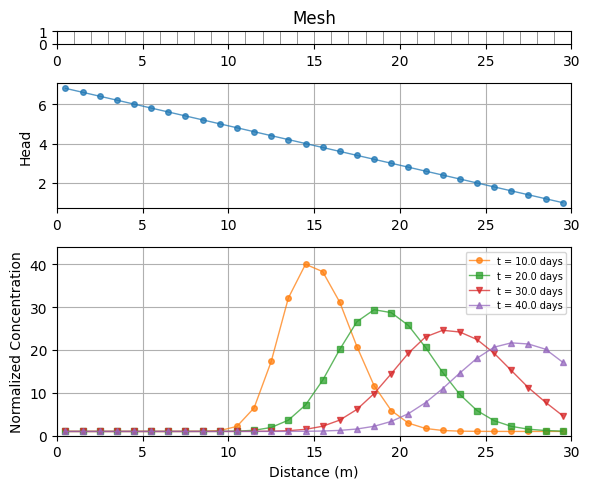

In [9]:
# --- Recuperamos los resultados de flujo de la simulación ---
# TODO: checar si se puede recuperar la información del objeto o_gwf directamente.
head = xmf6.gwf.get_head(o_gwf)
qx, qy, qz, n_q = xmf6.gwf.get_specific_discharge(o_gwf, text="DATA-SPDIS")

# --- Recuperamos los resultados de la concentración de la simulación ---
cobj = o_gwt.output.concentration()

# --- Recuperamos las coordenadas del dominio
x, y, z = o_gwf.modelgrid.xyzcellcenters
row_length = o_gwf.modelgrid.extent[1]

# --- Definición de la figura ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize =(6,5), 
                                    height_ratios=[0.1,1.0,1.5])

# --- Gráfica 1. Malla ---
pmv = flopy.plot.PlotMapView(o_gwf, ax=ax1)
pmv.plot_grid(colors='dimgray', lw=0.5)
ax1.set_yticks(ticks=[0, 1.0])#, fontsize=8)
ax1.set_title("Mesh")

# --- Gráfica 2. Carga hidráulica---
ax2.plot(x[0], head[0, 0], marker="o", lw =1.0, #mec="blue", mfc="none", 
         markersize="4", alpha = 0.75, label = 'Head')
ax2.set_xlim(0, 30)
ax2.set_ylabel("Head")
ax2.grid()

# --- Gráfica 3. Concentración ---
# Define los tiempos de interés
t1 = 10.0
t2 = 20.0
t3 = 30.0
t4 = 40.0

# Obtención de los datos de concentración simulados para cada tiempo
conc_t1 = cobj.get_data(totim=t1).flatten()
conc_t2 = cobj.get_data(totim=t2).flatten()
conc_t3 = cobj.get_data(totim=t3).flatten()
conc_t4 = cobj.get_data(totim=t4).flatten()

# Crear la gráfica en formato de líneas para ambos tiempos
ax3.plot(x[0], conc_t1, ls ="-", lw = 1.0, c = "C1", 
         marker ="o", markersize="4", alpha = 0.75,
         label=f"t = {t1} days", zorder=2)
ax3.plot(x[0], conc_t2, ls ="-", lw = 1.0, c = "C2", 
         marker="s", markersize="4", alpha = 0.75,
         label=f"t = {t2} days", zorder=2)
ax3.plot(x[0], conc_t3, ls ="-", lw = 1.0, c = "C3", 
         marker="v", markersize="4", alpha = 0.75,
         label=f"t = {t3} days", zorder=2)
ax3.plot(x[0], conc_t4, ls ="-", lw = 1.0, c = "C4", 
         marker="^", markersize="4", alpha = 0.75,
         label=f"t = {t4} days", zorder=2)

ax3.set_xlabel("Distance (m)")
ax3.set_ylabel("Normalized Concentration")
ax3.set_xlim(0, 30)
ax3.grid()

# Ajusta el límite superior del eje Y basado en el valor máximo de ambos conjuntos de datos
max_y = max(conc_t1.max(), conc_t2.max(), conc_t3.max(), conc_t4.max())
ax3.set_ylim(0, max_y * 1.1)
ax3.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

obs_df = pd.read_csv("output_1D_u/transport_obs.csv")

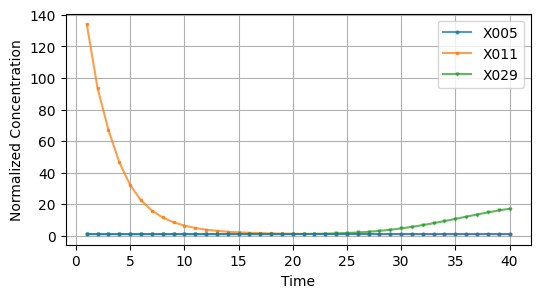

In [11]:
plt.figure(figsize=(6,3))
plt.plot(obs_df['time'], obs_df['X005'],marker="o",markersize="2",alpha=0.75,label="X005", zorder=5)
plt.plot(obs_df['time'], obs_df['X011'],marker="s",markersize="2",alpha=0.75,label="X011")
plt.plot(obs_df['time'], obs_df['X029'],marker="v",markersize="2",alpha=0.75,label="X029")
plt.xlabel("Time")
plt.ylabel("Normalized Concentration")
plt.legend()
plt.grid()
plt.show()

In [ ]:
obs_df